In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv(r"G:\internship\parkinsons.data")
df["subject_id"] = df["name"].str.split("_").str[2]

In [4]:
print(df.head())

             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

       NHR     HNR  status      RPDE       DFA   spread1   spread2        D2  \
0  0.0

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 17  status  

In [6]:
print(df.describe())

       MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
count   195.000000    195.000000    195.000000      195.000000   
mean    154.228641    197.104918    116.324631        0.006220   
std      41.390065     91.491548     43.521413        0.004848   
min      88.333000    102.145000     65.476000        0.001680   
25%     117.572000    134.862500     84.291000        0.003460   
50%     148.790000    175.829000    104.315000        0.004940   
75%     182.769000    224.205500    140.018500        0.007365   
max     260.105000    592.030000    239.170000        0.033160   

       MDVP:Jitter(Abs)    MDVP:RAP    MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
count        195.000000  195.000000  195.000000  195.000000    195.000000   
mean           0.000044    0.003306    0.003446    0.009920      0.029709   
std            0.000035    0.002968    0.002759    0.008903      0.018857   
min            0.000007    0.000680    0.000920    0.002040      0.009540   
25%            0.000

In [7]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
subject_id          0
dtype: int64


In [8]:
print(df.shape)

(195, 25)


In [9]:
print(df["status"].value_counts())

status
1    147
0     48
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_14564\306892116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["status"], palette=["#4c72b0", "#c44e52"])


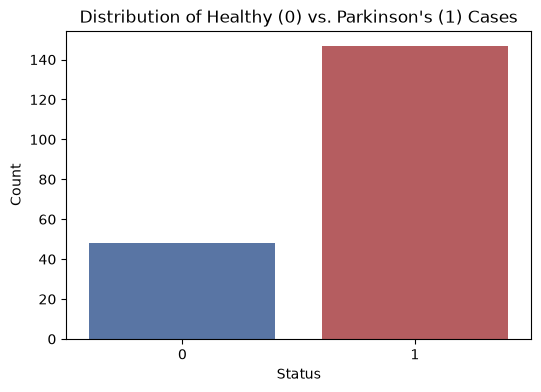

In [10]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=df["status"], palette=["#4c72b0", "#c44e52"])
plt.title("Distribution of Healthy (0) vs. Parkinson's (1) Cases", fontsize=12)
plt.xlabel("Status", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.show()

In [11]:
subj_labels = df.groupby("subject_id")["status"].first()

In [12]:
subj_labels

subject_id
S01    1
S02    1
S04    1
S05    1
S06    1
S07    0
S08    1
S10    0
S13    0
S16    1
S17    0
S18    1
S19    1
S20    1
S21    1
S22    1
S24    1
S25    1
S26    1
S27    1
S31    1
S32    1
S33    1
S34    1
S35    1
S37    1
S39    1
S42    0
S43    0
S44    1
S49    0
S50    0
Name: status, dtype: int64

In [13]:
train_patients, test_patients = train_test_split(
    subj_labels.index, 
    test_size=0.20, 
    random_state=42,
    stratify=subj_labels.values)

In [14]:
train_data = df[df["subject_id"].isin(train_patients)]
test_data  = df[df["subject_id"].isin(test_patients)]

X_train = train_data.drop(columns=["name", "status", "subject_id"])
y_train = train_data["status"]
groups_train = train_data["subject_id"] # Needed to ensure patients stay grouped during RFECV

X_test = test_data.drop(columns=["name", "status", "subject_id"])
y_test = test_data["status"]


In [15]:
rf_model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)


In [16]:
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
rfecv = RFECV(estimator=rf_model, cv=cv_strategy, scoring="accuracy")

In [18]:
X_train_reduced = rfecv.fit_transform(X_train, y_train, groups=groups_train)
X_test_reduced = rfecv.transform(X_test)

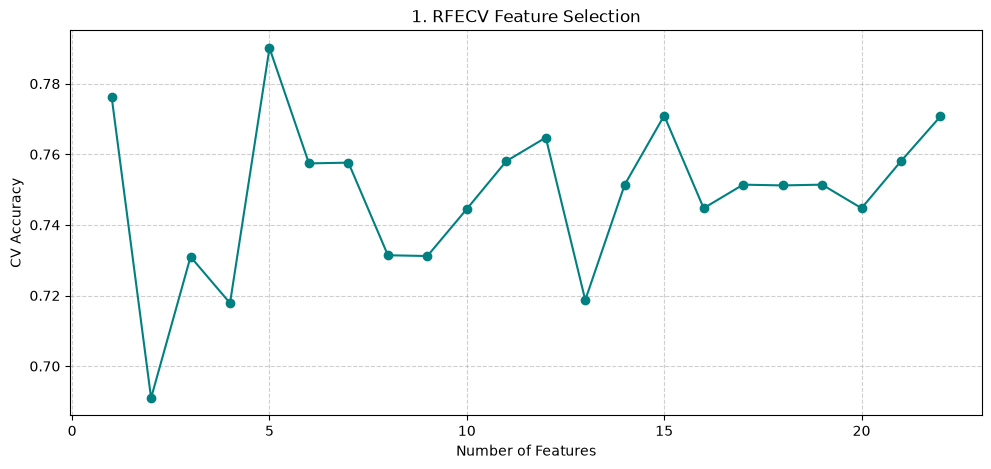

In [19]:
fig = plt.figure(figsize=(40, 5))
plt.subplot(1, 3, 1)
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1), rfecv.cv_results_["mean_test_score"], marker="o", color="teal")
plt.xlabel("Number of Features")
plt.ylabel("CV Accuracy")
plt.title("1. RFECV Feature Selection")
plt.grid(True, linestyle="--", alpha=0.6)

In [20]:
print(f"Features kept: {rfecv.n_features_}")

Features kept: 5


In [24]:
selected_features = X_train.columns[rfecv.support_].tolist()

print("Selected Features:", selected_features)

Selected Features: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'NHR', 'spread1', 'PPE']


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "SVM": SVC(kernel="rbf", class_weight="balanced", random_state=42), 
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=3) 
}


In [27]:
model_names = list(models.keys())
accuracies = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, target_names=["Healthy", "PD"], zero_division=0))


=== Logistic Regression ===
Accuracy: 0.860
              precision    recall  f1-score   support

     Healthy       0.88      0.58      0.70        12
          PD       0.86      0.97      0.91        31

    accuracy                           0.86        43
   macro avg       0.87      0.78      0.80        43
weighted avg       0.86      0.86      0.85        43


=== SVM ===
Accuracy: 0.884
              precision    recall  f1-score   support

     Healthy       1.00      0.58      0.74        12
          PD       0.86      1.00      0.93        31

    accuracy                           0.88        43
   macro avg       0.93      0.79      0.83        43
weighted avg       0.90      0.88      0.87        43


=== Random Forest ===
Accuracy: 0.907
              precision    recall  f1-score   support

     Healthy       1.00      0.67      0.80        12
          PD       0.89      1.00      0.94        31

    accuracy                           0.91        43
   macro avg   

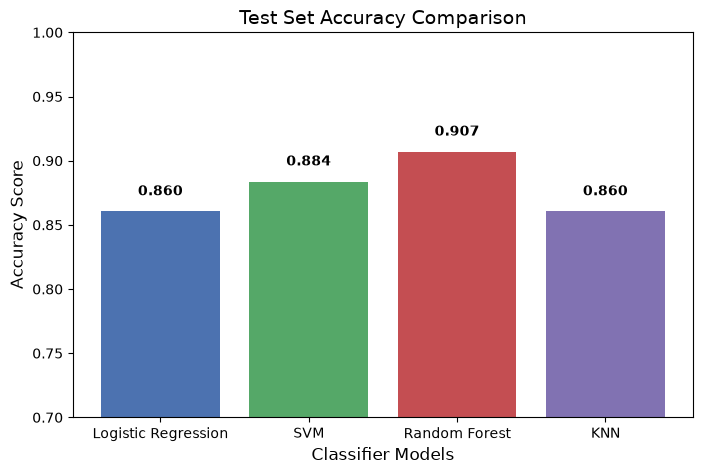

In [28]:
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])

plt.xlabel("Classifier Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.title("Test Set Accuracy Comparison", fontsize=14)
plt.ylim(0.7, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 0.01, 
        f"{height:.3f}", 
        ha="center", 
        va="bottom", 
        fontweight="bold"
    )
plt.show()

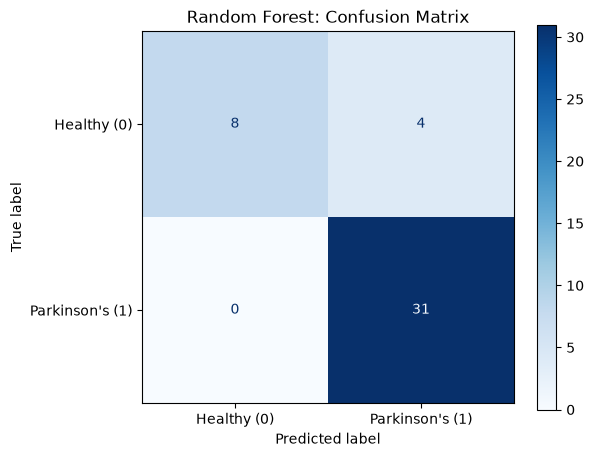

In [29]:
best_model = models["Random Forest"]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_model, 
    X_test_scaled, 
    y_test, 
    display_labels=["Healthy (0)", "Parkinson's (1)"],
    cmap="Blues",
    ax=ax
)
plt.title("Random Forest: Confusion Matrix")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14564\1493319638.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=selected_features, palette="viridis")


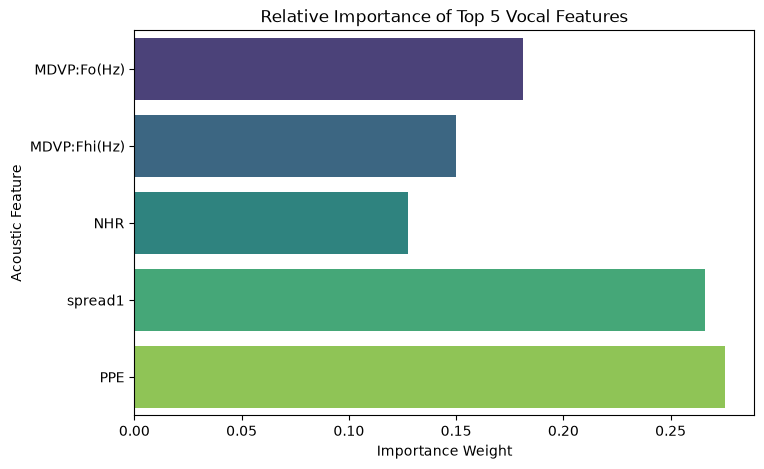

In [ ]:
importances = best_model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=selected_features, palette="viridis")
plt.title("Relative Importance of Top 5 Vocal Features")
plt.xlabel("Importance Weight")
plt.ylabel("Acoustic Feature")
plt.show()